In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [3]:
len(words)

32033

In [5]:
from string import ascii_lowercase
stoi = {s:i+1 for i, s in enumerate(ascii_lowercase)}
stoi['$'] = 0

itos = {i:s for s, i in stoi.items()}

## Build the Dataset

In [18]:
block_size = 3
X, y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '$':
        ix = stoi[ch]
        X.append(context)
        y.append(ix)
        # print(''.join(itos[i] for i in context), '-->', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
y = torch.tensor(y)

In [19]:
X.shape, y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [20]:
C = torch.randn(size=(27, 2))

In [21]:
C[:10]

tensor([[-1.5410, -0.6534],
        [ 0.8814, -1.2039],
        [ 0.2268, -0.9489],
        [ 0.6508, -1.1606],
        [ 0.2729,  0.9646],
        [-0.6491, -1.1571],
        [ 0.1561,  0.3867],
        [-1.1993,  0.7858],
        [-0.7017, -0.1027],
        [ 1.3596,  1.5563]])

In [22]:
X[:2, :]

tensor([[0, 0, 0],
        [0, 0, 5]])

In [23]:
C[X[:2, :]]

tensor([[[-1.5410, -0.6534],
         [-1.5410, -0.6534],
         [-1.5410, -0.6534]],

        [[-1.5410, -0.6534],
         [-1.5410, -0.6534],
         [-0.6491, -1.1571]]])

In [25]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.6491, -1.1571])

In [26]:
C[5] # Better to use this one

tensor([-0.6491, -1.1571])

In [27]:
embeddings = C[X]
embeddings.shape

torch.Size([228146, 3, 2])

In [28]:
C.shape, X.shape

(torch.Size([27, 2]), torch.Size([228146, 3]))

In [29]:
print(embeddings[0]) # $$$
embeddings[1] # $$e 

tensor([[-1.5410, -0.6534],
        [-1.5410, -0.6534],
        [-1.5410, -0.6534]])


tensor([[-1.5410, -0.6534],
        [-1.5410, -0.6534],
        [-0.6491, -1.1571]])

In [30]:
W1 = torch.randn(6, 100) # 2 embeddings for 3 letters (32, 3, 2) 32 words 3 letters 2 embeddings
B1 = torch.randn(100)

In [17]:
# embeddings @ W1 + B1

In [31]:
torch.cat([embeddings[:, 0, :], embeddings[:, 1, :], embeddings[:, 2, :]], dim=1).shape
# This is not efficient and it takes more memory and it is HardCoded for x letters i.e, here 3

torch.Size([228146, 6])

In [32]:
# https://docs.pytorch.org/docs/stable/generated/torch.unbind.html

print(embeddings.shape)
emb_v2 = torch.cat(torch.unbind(embeddings, dim=1), dim=1)
emb_v2.shape

# Still {cat} is not efficient to use

torch.Size([228146, 3, 2])


torch.Size([228146, 6])

In [33]:
emb_v2[:3]

tensor([[-1.5410, -0.6534, -1.5410, -0.6534, -1.5410, -0.6534],
        [-1.5410, -0.6534, -1.5410, -0.6534, -0.6491, -1.1571],
        [-1.5410, -0.6534, -0.6491, -1.1571,  0.5622, -1.2660]])

In [34]:
a = torch.arange(18)
print(a.shape)

a.view(3, 3, 2)

torch.Size([18])


tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [35]:
a.storage()
# This is created my Pytorch that will store all the values in a One Dimensional Array in the Computer Memory

/tmp/ipykernel_20398/2967741135.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [36]:
emb_v2[:3]

tensor([[-1.5410, -0.6534, -1.5410, -0.6534, -1.5410, -0.6534],
        [-1.5410, -0.6534, -1.5410, -0.6534, -0.6491, -1.1571],
        [-1.5410, -0.6534, -0.6491, -1.1571,  0.5622, -1.2660]])

In [37]:
embeddings.view(X.shape[0], 6)[:3]

tensor([[-1.5410, -0.6534, -1.5410, -0.6534, -1.5410, -0.6534],
        [-1.5410, -0.6534, -1.5410, -0.6534, -0.6491, -1.1571],
        [-1.5410, -0.6534, -0.6491, -1.1571,  0.5622, -1.2660]])

In [38]:
embeddings.view(X.shape[0], 6)[:3] == emb_v2[:3]

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True]])

In [39]:
# Instead of using Cat and those hardcoded ones, we can use this VIEW

h = torch.tanh(embeddings.view(embeddings.shape[0], 6) @ W1 + B1)

# (32, 6) @ (6, 100) + B1
# (32, 100) + (100)
# 32, 100
#     100

# Broadcasting Semantics
# 32, 100
#  1, 100

In [40]:
h

tensor([[-1.0000, -1.0000,  0.9970,  ...,  0.9998,  1.0000, -0.9991],
        [-1.0000, -0.9994,  0.9972,  ...,  0.9989,  0.9999, -0.9902],
        [-0.9988, -0.9212,  0.9672,  ...,  0.9790,  0.9928, -0.9473],
        ...,
        [ 0.5086,  0.2958,  0.9997,  ..., -0.8239,  0.2257,  0.8798],
        [ 0.2723, -0.8683,  0.8230,  ..., -0.4757,  0.8146, -0.8960],
        [-0.7246, -0.9632,  0.8009,  ...,  0.9074,  0.6146,  0.3591]])

In [41]:
h.shape

torch.Size([228146, 100])

In [42]:
W2 = torch.randn((100, 27))
B2 = torch.randn(27)

In [43]:
logits = h @ W2 + B2
logits.shape

torch.Size([228146, 27])

In [44]:
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs.shape

torch.Size([228146, 27])

In [45]:
probs[0].sum()

tensor(1.)

In [46]:
probs[torch.arange(X.shape[0]), y] # Correct character sequence probabilites

tensor([2.4520e-07, 2.5931e-15, 5.2541e-15,  ..., 3.9297e-07, 1.2869e-04,
        2.5944e-13])

In [47]:
loss = -probs[torch.arange(X.shape[0]), y].log().mean()
loss

tensor(20.0111)

### Clean Code V01

In [48]:
X.shape, y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [79]:
g = torch.Generator().manual_seed(2147483647)

C = torch.randn(size=(27, 2), generator=g)

W1 = torch.randn(size=(6, 100), generator=g)
B1 = torch.randn(100, generator=g)

W2 = torch.randn((100, 27), generator=g)
B2 = torch.randn(27, generator=g)

parameters = [C, W1, B1, W2, B2]

In [80]:
sum(p.nelement() for p in parameters) # Total Number of Parameters in the model

3481

In [81]:
# embeddings = C[X] # (32, 3, 2)
# h = torch.tanh(embeddings.view(-1, 6) @ W1 + B1) # (32, 100)
# logits = h @ W2 + B2 # (32, 27)
# counts = logits.exp()
# probs = counts / counts.sum(1, keepdim=True)
# loss = -probs[torch.arange(X.shape[0]), y].log().mean()
# loss

In [82]:
# F.cross_entropy(logits, y)

# Preferable to use this one for Loss. cause we are creating more tensors above and we are not using any optimization clusters. Pytorch internally use some optimization clusters to efficently execute the loss
# Logits = [-10, 2, 3, 100] -> e^-10 Ok, e^2 Ok, e^3 Ok, e^100 Not Okey
# e^100 is a very large number and when we do the normalization -> LargerNumber / (LargerNumber + VerySmallNumber) It will end in {Inf} 0.0000000000000000000000000043 like that it can't fit in a float or any data type so that i comes as Inf
# Pytorch will do something like Logits - max(Logits) => [-110, -98, -97, 0] these all can be represented in floats, Like these optimization things pytorch will do.

In [83]:
for p in parameters:
    p.requires_grad = True

#### How to Find a Good Learning Rate
Reset the parameters everytime. !Important   
try different learning rates like 0.0001, 0.001, 0.01, 0.1, 1, 10, & 100.  
from these, you can find a window of two LRs where the loss is quite perfomring well.  
Let's say for 0.0001, the loss is very slowly decreasing.  
For 0.001, the loss is decreasing quite well.  
For 1, the loss is fluctuating a lot and not decreasing.  
For 10, the loss is diverging and increasing.  

You can see that the window of good learning rates is between 0.001 and 1.


In [84]:
# 0.001 -> 10^-3
# 1 -> 10^0

lr_exp = torch.linspace(-3, 0, 1000)
lr_exp[:5]

tensor([-3.0000, -2.9970, -2.9940, -2.9910, -2.9880])

In [85]:
lr_exp_i = []
loss_i = []

for i in range(1000):
    # MiniBatch Selection
    ix = torch.randint(0, X.shape[0], (32, ))
    # Forward Pass
    embeddings = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(embeddings.view(-1, 6) @ W1 + B1) # (32, 100)
    logits = h @ W2 + B2 # (32, 27)
    loss = F.cross_entropy(logits, y[ix])

    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update Step
    lr = 10**(lr_exp[i])
    for p in parameters:
        p.data += -lr * p.grad
    
    # Track Stats
    lr_exp_i.append(lr_exp[i])
    loss_i.append(loss.item())
# print(loss.item())

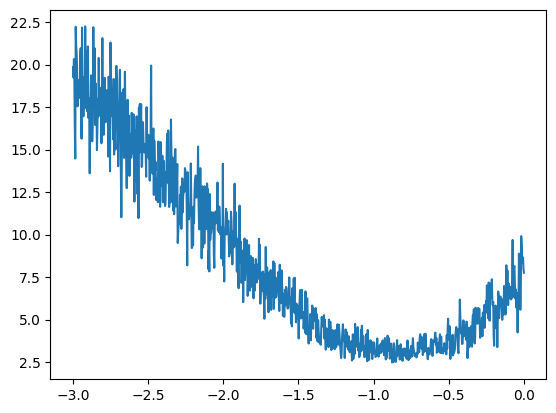

In [90]:
plt.plot(lr_exp_i, loss_i)

In [91]:
# The Sweet Spot for Learning Rate we found is at -1.0 i.e, 10^(-1.0) = 0.1
LR = 0.1

In [92]:
for epoch in range(100):
    # MiniBatch Selection
    ix = torch.randint(0, X.shape[0], (32, ))
    # Forward Pass
    embeddings = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(embeddings.view(-1, 6) @ W1 + B1) # (32, 100)
    logits = h @ W2 + B2 # (32, 27)
    loss = F.cross_entropy(logits, y[ix])

    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update Step
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad
print(loss.item())

2.69091796875


In [93]:
embeddings = C[X] # (32, 3, 2)
h = torch.tanh(embeddings.view(-1, 6) @ W1 + B1) # (32, 100)
logits = h @ W2 + B2 # (32, 27)
loss = F.cross_entropy(logits, y)
loss

tensor(3.0101, grad_fn=<NllLossBackward0>)

### Building Dataset -> Train, Test, & Validation Sets

In [94]:
def build_dataset(words):
    block_size = 3
    X, y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '$':
            ix = stoi[ch]
            X.append(context)
            y.append(ix)
            # print(''.join(itos[i] for i in context), '-->', itos[ix])
            context = context[1:] + [ix]
    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y

import random
random.seed(42)
random.shuffle(words)

n1 = int(.8 * len(words))
n2 = int(.9 * len(words))

X_train, y_train = build_dataset(words[:n1])
X_valid, y_valid = build_dataset(words[n1:n2])
X_test, y_test = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [95]:
X_train.shape, y_train.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [96]:
g = torch.Generator().manual_seed(2147483647)

C = torch.randn(size=(27, 10), generator=g)

W1 = torch.randn(size=(30, 200), generator=g)
B1 = torch.randn(200, generator=g)

W2 = torch.randn((200, 27), generator=g)
B2 = torch.randn(27, generator=g)

parameters = [C, W1, B1, W2, B2]

In [97]:
sum(p.nelement() for p in parameters) # Total Number of Parameters in the model

11897

In [98]:
for p in parameters:
    p.requires_grad = True

In [99]:
lr_exp_i = []
loss_i = []
step_i = []

In [100]:
for i in range(50000):
    # MiniBatch Selection
    ix = torch.randint(0, X_train.shape[0], (32, ))
    # Forward Pass
    embeddings = C[X_train[ix]] # (32, 3, 2)
    h = torch.tanh(embeddings.view(-1, 30) @ W1 + B1) # (32, 100)
    logits = h @ W2 + B2 # (32, 27)
    loss = F.cross_entropy(logits, y_train[ix])

    # Backward Pass 
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update Step
    lr = 0.1
    for p in parameters:
        p.data += -0.1 * p.grad
    
    step_i.append(i)
    loss_i.append(loss.log10().item())
print(loss.item())

2.7195727825164795


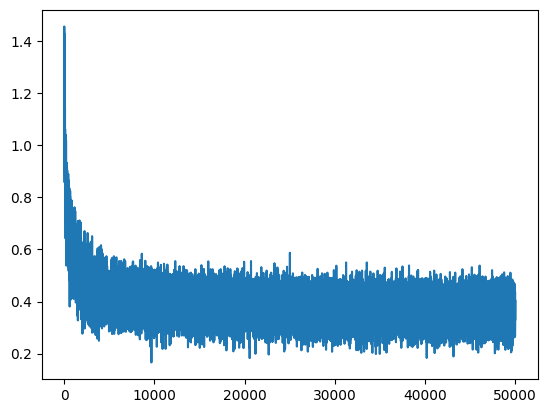

In [101]:
plt.plot(step_i, loss_i)

In [103]:
embeddings = C[X_train]
h = torch.tanh(embeddings.view(-1, 30) @ W1 + B1)
logits = h @ W2 + B2
loss = F.cross_entropy(logits, y_train)
loss

tensor(2.3109, grad_fn=<NllLossBackward0>)

In [104]:
embeddings = C[X_valid] # (32, 3, 2)
h = torch.tanh(embeddings.view(- 1, 30) @ W1 + B1) # (32, 100)
logits = h @ W2 + B2 # (32, 27)
loss = F.cross_entropy(logits, y_valid)
loss

tensor(2.3287, grad_fn=<NllLossBackward0>)

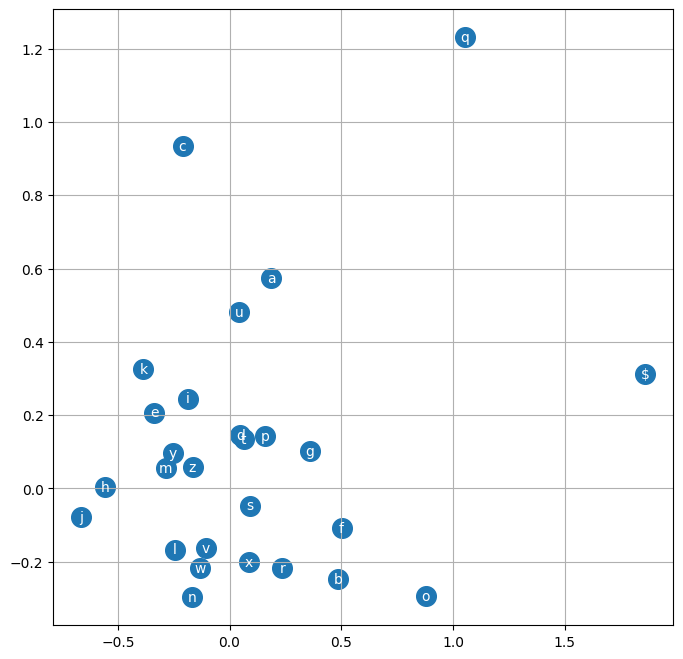

In [105]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
plt.grid("minor")

In [108]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(10):
    out = []
    context = [0] * block_size
    while True:
        embeddings = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(embeddings.view(1, -1) @ W1 + B1)
        logits = h @ W2 + B2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        out.append(ix)
        context = context[1:] + [ix] # For next character generation block_size sequence
        if ix == 0:
            break
    print(''.join(itos[i] for i in out[:-1]))

dex
maiem
kurison
kayen
vazimitta
malka
kyn
kay
sayzyeub
tahry
